# Digital Ecosystem Readiness Index (ITU Indicators)

## Project overview

This notebook presents an exploratory analysis of selected Information and Communication Technology (ICT) indicators published by the **International Telecommunication Union (ITU)** via the ITU DataHub.

The objective of the analysis is to construct a **lightweight Digital Ecosystem Readiness Index**, combining key dimensions of digital development:
- Access
- Usage
- Infrastructure
- Affordability
- Cybersecurity

The analysis is designed to be:
- transparent,
- reproducible,
- policy-relevant,
- and easy to interpret by non-technical stakeholders.

All charts are rendered directly in the notebook and saved to the `figures/` folder.

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths (notebook is inside /notebook)
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Create figures directory if it does not exist
FIGURES_DIR.mkdir(exist_ok=True)

# Visualization style
sns.set_theme(style="whitegrid")

## Data sources

All datasets used in this analysis were obtained from the **ITU DataHub**
https://datahub.itu.int

### Selected indicators

| Dimension | Indicator | ITU series code |
|---------|----------|-----------------|
| Access | Households with Internet access at home | xHH6_IDI |
| Usage | Individuals using the Internet | i99H |
| Infrastructure | Population coverage (at least 2G) | i271pop |
| Affordability | Mobile broadband low-consumption basket (1 GB) | i271mb_low_1GB$ |
| Cybersecurity | Global Cybersecurity Index – Overall Score | gci_overall |

For each indicator, the **latest available year per country** is used.

In [183]:
# Load CSV files
df_usage = pd.read_csv(DATA_DIR / "individuals_using_internet.csv")
df_access = pd.read_csv(DATA_DIR / "households_internet_access.csv")
df_infra = pd.read_csv(DATA_DIR / "population_coverage_mobile.csv")
df_afford = pd.read_csv(DATA_DIR / "mobile_broadband_affordability.csv")
df_trust = pd.read_csv(DATA_DIR / "cybersecurity_index.csv")

# Preview one dataset
df_usage.head()

,seriesID,seriesCode,seriesName,seriesParent,seriesUnits,entityID,entityIso,entityName,dataValue,dataYear,dataNote,dataSource,seriesDescription
0,11624,i99H,Individuals using the Internet,NaN,%,4,ABW,Aruba,15.4428,2000,NaN,Servicio di Telecomunicacion di Aruba (SETAR).,Refers to the proportion of individuals who us...
1,11624,i99H,Individuals using the Internet,NaN,%,4,ABW,Aruba,17.1000,2001,NaN,ITU estimate.,Refers to the proportion of individuals who us...
2,11624,i99H,Individuals using the Internet,NaN,%,4,ABW,Aruba,18.8000,2002,NaN,ITU estimate.,Refers to the proportion of individuals who us...
3,11624,i99H,Individuals using the Internet,NaN,%,4,ABW,Aruba,20.8000,2003,NaN,ITU estimate.,Refers to the proportion of individuals who us...
4,11624,i99H,Individuals using the Internet,NaN,%,4,ABW,Aruba,23.0000,2004,NaN,ITU estimate.,Refers to the proportion of individuals who us...


In [184]:
def keep_latest_year(df):
    return (
        df.sort_values("dataYear")
          .groupby("entityIso", as_index=False)
          .tail(1)
    )

df_usage = keep_latest_year(df_usage)
df_access = keep_latest_year(df_access)
df_infra = keep_latest_year(df_infra)
df_afford = keep_latest_year(df_afford)
df_trust = keep_latest_year(df_trust)

## Methodology

1. For each indicator, the most recent observation per country is selected.
2. Indicators are normalized to a 0–1 scale using min–max normalization.
3. The affordability indicator is inverted, as lower cost indicates higher readiness.
4. All indicators are equally weighted.
5. A composite **Digital Ecosystem Readiness Index** is calculated as the arithmetic mean of normalized indicators.

This approach prioritizes simplicity and transparency over complex weighting schemes.

In [185]:
# Base dataset: Individuals using the Internet
df_all = df_usage[["entityIso", "entityName", "dataValue"]].copy()
df_all.rename(columns={
    "entityIso": "CountryCode",
    "entityName": "Country",
    "dataValue": "Internet_Usage"
}, inplace=True)

# Merge other indicators
df_all = df_all.merge(
    df_access[["entityIso", "dataValue"]],
    left_on="CountryCode",
    right_on="entityIso",
    how="left"
).rename(columns={"dataValue": "Household_Access"}).drop(columns=["entityIso"])

df_all = df_all.merge(
    df_infra[["entityIso", "dataValue"]],
    left_on="CountryCode",
    right_on="entityIso",
    how="left"
).rename(columns={"dataValue": "Mobile_Coverage"}).drop(columns=["entityIso"])

df_all = df_all.merge(
    df_afford[["entityIso", "dataValue"]],
    left_on="CountryCode",
    right_on="entityIso",
    how="left"
).rename(columns={"dataValue": "Affordability"}).drop(columns=["entityIso"])

df_all = df_all.merge(
    df_trust[["entityIso", "dataValue"]],
    left_on="CountryCode",
    right_on="entityIso",
    how="left"
).rename(columns={"dataValue": "Cybersecurity"}).drop(columns=["entityIso"])

df_all.head()

,CountryCode,Country,Internet_Usage,Household_Access,Mobile_Coverage,Affordability,Cybersecurity
0,MYT,Mayotte,1.21153,NaN,66.39,NaN,NaN
1,TKL,Tokelau,1.49589,19.5122,0.00,17.03,NaN
2,PLW,Palau,26.97030,50.3063,95.00,26.67,5.3
3,GUF,French Guiana,25.70340,NaN,85.28,25.25,NaN
4,REU,Réunion,36.27920,17.0000,89.64,NaN,NaN


In [186]:
df_all.isna().sum()

CountryCode          0
Country              0
Internet_Usage       0
Household_Access     9
Mobile_Coverage      0
Affordability       13
Cybersecurity       34
dtype: int64

In [187]:
df_clean = df_all.dropna().reset_index(drop=True)
df_clean.shape

(190, 7)

In [188]:
from sklearn.preprocessing import MinMaxScaler

# List of indicators to normalize
indicators = [
    "Internet_Usage",
    "Household_Access",
    "Mobile_Coverage",
    "Affordability",
    "Cybersecurity"
]

# Normalize all indicators to a 0-1 scale
scaler = MinMaxScaler()
df_clean[indicators] = scaler.fit_transform(df_clean[indicators])

# Invert Affordability: lower cost means higher readiness
df_clean["Affordability"] = 1 - df_clean["Affordability"]

# Calculate the composite Digital Ecosystem Readiness Index
df_clean["Digital_Ecosystem_Index"] = df_clean[indicators].mean(axis=1)

# Display the first 5 rows for verification
df_clean.head()

,CountryCode,Country,Internet_Usage,Household_Access,Mobile_Coverage,Affordability,Cybersecurity,Digital_Ecosystem_Index
0,PLW,Palau,0.210412,0.486795,0.950000,0.733641,0.005252,0.477220
1,VEN,Venezuela,0.584824,0.313285,0.000000,0.965676,0.375000,0.447757
2,TKM,Turkmenistan,0.148575,0.491558,0.980000,0.675231,0.221639,0.503401
3,CAF,Central African Rep.,0.000000,0.014183,0.595959,0.813529,0.000000,0.284734
4,SYR,Syrian Arab Republic,0.293444,0.432098,0.749800,0.866319,0.491597,0.566651


In [189]:
df_clean["Digital_Ecosystem_Index"] = df_clean[indicators].mean(axis=1)

df_clean.sort_values("Digital_Ecosystem_Index", ascending=False).head(10)

,CountryCode,Country,Internet_Usage,Household_Access,Mobile_Coverage,Affordability,Cybersecurity,Digital_Ecosystem_Index
184,LUX,Luxembourg,0.986600,0.988177,1.0000,0.910578,0.986345,0.974340
164,DNK,Denmark,0.997505,0.968141,1.0000,0.889803,1.000000,0.971090
109,ISL,Iceland,0.998163,0.983101,0.9920,0.851566,0.987395,0.962445
21,QAT,Qatar,0.996246,0.986750,1.0000,0.819149,1.000000,0.960429
83,GBR,United Kingdom,0.959983,0.962923,0.9990,0.858691,1.000000,0.956119
181,ARE,United Arab Emirates,1.000000,1.000000,0.9946,0.775191,1.000000,0.953958
171,SAU,Saudi Arabia,1.000000,1.000000,1.0000,0.750703,1.000000,0.950141
145,KOR,Korea (Rep. of),0.977247,0.999698,0.9990,0.764552,1.000000,0.948100
140,EST,Estonia,0.916078,0.926620,1.0000,0.941088,0.947479,0.946253
156,MYS,Malaysia,0.978599,0.967005,0.9860,0.810819,0.987395,0.945964


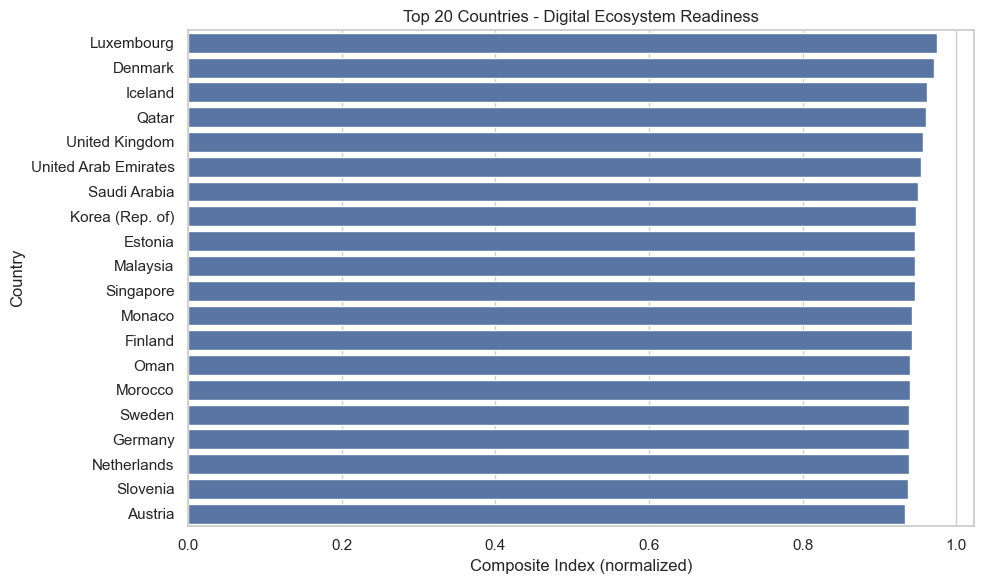

In [190]:
top20 = df_clean.sort_values(
    "Digital_Ecosystem_Index", ascending=False
).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20,
    y="Country",
    x="Digital_Ecosystem_Index"
)

plt.title("Top 20 Countries - Digital Ecosystem Readiness")
plt.xlabel("Composite Index (normalized)")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "top20_digital_ecosystem_index.png", dpi=300)
plt.show()

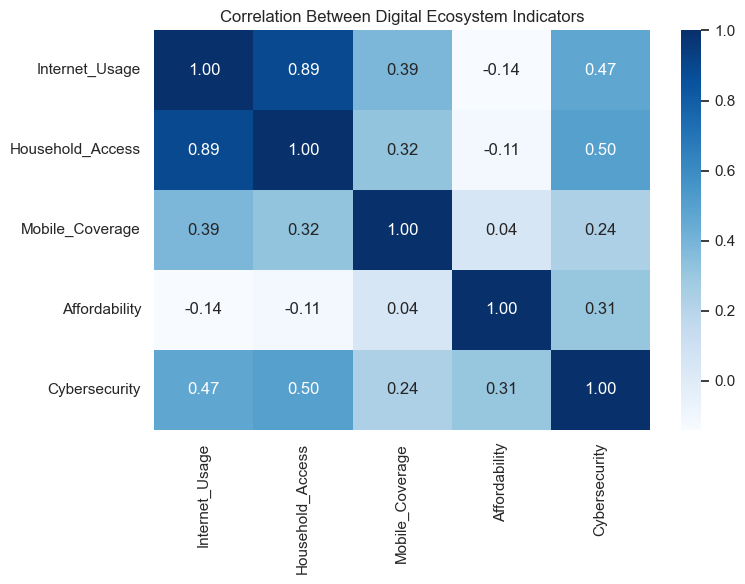

In [191]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_clean[indicators].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Digital Ecosystem Indicators")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "indicator_correlation_heatmap.png", dpi=300)
plt.show()

In [192]:
df_clean.to_csv(
    PROJECT_ROOT / "digital_ecosystem_readiness_index.csv",
    index=False
)